# 🌊 Ocean Debris Detection — Sentinel-2 + Google Earth Engine

**Pipeline:**
1. Authenticate & connect to GEE project `ml-marine-debris`
2. Fetch Sentinel-2 imagery over a target ocean region
3. Compute spectral indices (FDI, NDWI, PI)
4. Export image patches as a dataset
5. Train a U-Net segmentation model (PyTorch)
6. Run inference and visualise debris heatmap

> **Runtime:** GPU (T4 recommended) · **Estimated time:** ~30–45 min first run

##  Step 1 — Install Dependencies

1.   List item
2.   List item



In [ ]:
%%capture
!pip install earthengine-api geemap segmentation-models-pytorch \
             rasterio matplotlib folium torch torchvision \
             albumentations scikit-learn tqdm numpy pillow

print(' All packages installed.')

##  Step 2 — Authenticate Google Earth Engine

In [ ]:
import ee

# Authenticate — opens a browser tab the first time
ee.Authenticate()

# Initialise with your GEE project
PROJECT = 'ml-marine-debris-868'
ee.Initialize(project=PROJECT)

print(f' Connected to GEE project: {PROJECT}')

 Connected to GEE project: ml-marine-debris-868


## 🛰️ Step 3 — Define Study Area & Fetch Sentinel-2 Imagery

We use **Sentinel-2 Level-2A** (surface reflectance, atmospherically corrected).  
Default region: **South-East Asian seas** (high known debris density). Change `ROI_COORDS` to any ocean area.

In [ ]:
import geemap
import ee

# ── Region of Interest ──────────────────────────────────────────────────────
ROI_COORDS = [
    [100.0, 5.0],
    [104.0, 5.0],
    [104.0, 9.0],
    [100.0, 9.0],
    [100.0, 5.0],
]
roi = ee.Geometry.Polygon(ROI_COORDS)

# ── Date range ───────────────────────────────────────────────────────────────
START_DATE = '2024-01-01'
END_DATE   = '2024-06-30'

# ── OCEAN_MASK (built FIRST so we can mask the composite before computing FDI)
# Rasterise LSIB land polygons, then invert → ocean = 1, land = 0.
lsib = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017')
lsib_with_val = lsib.map(lambda f: f.set('land', 1))
land_raster = lsib_with_val.reduceToImage(
    properties = ['land'],
    reducer    = ee.Reducer.first()
)  # 1 inside land polygons, masked (no-data) outside

# .unmask(0) → land=1, ocean=0  |  .Not() → land=0, ocean=1
lsib_ocean = land_raster.unmask(0).Not()  # 1=ocean per LSIB, 0=land

# ── Load Sentinel-2 SR collection ────────────────────────────────────────────
def mask_s2_clouds(image):
    """Mask clouds using the Sentinel-2 QA60 band."""
    qa = image.select('QA60')
    cloud_bit_mask  = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
           qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask).divide(10000)

s2 = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(roi)
      .filterDate(START_DATE, END_DATE)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
)
print(f' Images found: {s2.size().getInfo()}')

# ── NDWI second-pass: remove small islands LSIB missed ──────────────────
# Reuse the same s2 collection (mask_s2_clouds already defined above).
# NDWI = (Green - NIR) / (Green + NIR): water > 0, land/veg/island < 0.
ndwi_composite = s2.median().clip(roi)
ndwi_water = ndwi_composite.normalizedDifference(['B3', 'B8']).gt(0)
# ndwi_water = 1 where NDWI > 0 (open water), 0 elsewhere (land/island)

# Final mask: LSIB says ocean AND NDWI confirms water
OCEAN_MASK = lsib_ocean.And(ndwi_water)
print(' OCEAN_MASK built: LSIB_SIMPLE base + NDWI>0 second-pass.')
print('   Small islands missed by LSIB are now excluded via spectral check.')

# ── KEY FIX: mask composite to OCEAN pixels BEFORE computing any indices ─────
# High NIR reflectance from bare soil, urban rooftops, and vegetation edges
# mimics high FDI. If we compute FDI on the full composite first and then
# apply .And(OCEAN_MASK) afterwards, GEE resamples OCEAN_MASK to the FDI
# native scale and loses boundary precision — land bleeds through.
#
# Solution: updateMask(OCEAN_MASK) on the raw composite first.
# Land pixels become no-data → FDI over land is never computed.
composite = s2.median().clip(roi).updateMask(OCEAN_MASK)
print(' Composite created and masked to ocean pixels.')
print('   Land pixels are no-data — FDI over land is impossible.')


 Images found: 153
 OCEAN_MASK built: LSIB_SIMPLE base + NDWI>0 second-pass.
   Small islands missed by LSIB are now excluded via spectral check.
 Composite created and masked to ocean pixels.
   Land pixels are no-data — FDI over land is impossible.


## 🔬 Step 4 — Compute Spectral Indices

| Index | Purpose | Key bands |
|-------|---------|----------|
| **FDI** | Floating Debris Index — detects floating plastic | NIR, Red, SWIR |
| **NDWI** | Water mask — separates sea from land | Green, NIR |
| **PI** | Plastic Index — plastic vs organic matter | NIR, Red |

In [ ]:
def compute_indices(image):
    """
    Compute FDI, NDWI, and PI on a Sentinel-2 image.
    Band mapping (S2):
      B3  = Green (560nm)
      B4  = Red   (665nm)
      B8  = NIR   (842nm)   — 10m
      B8A = NIR   (865nm)   — 20m (used in FDI)
      B11 = SWIR  (1610nm)  — 20m
    """
    NIR  = image.select('B8')
    NIR2 = image.select('B8A')   # narrowband NIR for FDI
    RED  = image.select('B4')
    GRN  = image.select('B3')
    SWIR = image.select('B11')

    # Floating Debris Index
    # FDI = NIR8A - (RED + (SWIR - RED) * (833-665)/(1610-665) * 10)
    lambda_factor = (833 - 665) / (1610 - 665)
    fdi = NIR2.subtract(
              RED.add(SWIR.subtract(RED).multiply(lambda_factor * 10))
          ).rename('FDI')

    # Normalised Difference Water Index  (Green-NIR)/(Green+NIR)
    ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')

    # Plastic Index  NIR / (NIR + Red)
    pi = NIR.divide(NIR.add(RED)).rename('PI')

    return image.addBands([fdi, ndwi, pi])


composite_idx = compute_indices(composite)
print(' Indices computed: FDI, NDWI, PI')

# Quick stats on FDI over the ROI
fdi_stats = composite_idx.select('FDI').reduceRegion(
    reducer=ee.Reducer.minMax().combine(ee.Reducer.mean(), sharedInputs=True),
    geometry=roi,
    scale=60,
    maxPixels=1e9
).getInfo()
print(f'FDI stats → {fdi_stats}')

 Indices computed: FDI, NDWI, PI
FDI stats → {'FDI_max': 0.27942222356796265, 'FDI_mean': 0.004299278614546238, 'FDI_min': -0.5184666423334016}


##  Step 5 — Visualise on Interactive Map

In [ ]:
import geemap
import ee

Map = geemap.Map(center=[7.0, 102.0], zoom=7)

# ── True Colour ──────────────────────────────────────────────────────────────
Map.addLayer(
    composite_idx,
    {'bands': ['B4','B3','B2'], 'min': 0, 'max': 0.3},
    'Sentinel-2 True Colour'
)

# ── FDI ──────────────────────────────────────────────────────────────────────
fdi_vis = {
    'bands': ['FDI'],
    'min': -0.05, 'max': 0.15,
    'palette': ['0000FF','00FFFF','00FF00','FFFF00','FF8800','FF0000']
}
Map.addLayer(composite_idx, fdi_vis, 'FDI (Floating Debris Index)')

# ── NDWI ─────────────────────────────────────────────────────────────────────
Map.addLayer(
    composite_idx.select('NDWI'),
    {'min': -0.3, 'max': 0.8, 'palette': ['brown','white','00AAFF']},
    'NDWI (Water Mask)'
)

# ── Debris mask ──────────────────────────────────────────────────────────────
# composite_idx was computed from an ocean-only composite (Step 3 updateMask),
# so land pixels are already masked (no-data). A simple FDI threshold suffices.
FDI_THRESHOLD = 0.04

# Debris = FDI above threshold.
# composite_idx is built from an ocean-only composite (masked in Step 3),
# so land pixels are already no-data — no .And(OCEAN_MASK) needed.
debris_mask = composite_idx.select('FDI').gt(FDI_THRESHOLD)

Map.addLayer(
    debris_mask.selfMask(),
    {'palette': ['FF0000'], 'opacity': 0.7},
    f'Debris Candidate (FDI > {FDI_THRESHOLD})'
)

# ── DEBUG: show OCEAN_MASK — should be BLUE over water, nothing over land ────
Map.addLayer(
    OCEAN_MASK.selfMask(),
    {'palette': ['0044FF'], 'opacity': 0.35},
    'LSIB Ocean Mask (debug — blue=ocean)',
    shown=True
)

Map.add_colorbar(fdi_vis, label='FDI', layer_name='FDI (Floating Debris Index)')

print(' Map ready.')
print(f'   FDI threshold : {FDI_THRESHOLD}')
print('   Land mask     : composite.updateMask(OCEAN_MASK) applied in Step 3')
print()
print('  CHECK: "LSIB Ocean Mask" blue should cover Gulf of Thailand water.')
print('    Red debris should appear ONLY inside the blue zone.')
Map


 Map ready.
   FDI threshold : 0.04
   Land mask     : composite.updateMask(OCEAN_MASK) applied in Step 3

  CHECK: "LSIB Ocean Mask" blue should cover Gulf of Thailand water.
    Red debris should appear ONLY inside the blue zone.


Map(center=[7.0, 102.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

## 📥 Step 6 — Export Image Patches for ML Training

Exports 256×256 patches (10 m/px) with all bands + indices to your **Google Drive** or **GCS bucket**.

In [ ]:
import math

# ── Export settings ──────────────────────────────────────────────────────────
EXPORT_SCALE  = 60      # 10m per pixel (Sentinel-2 native)
EXPORT_FOLDER = 'ocean_debris_patches'  # folder in your Google Drive

# Export only the 10 raw S2 bands — NOT FDI/NDWI/PI.
# Steps 12 & 13 compute those indices on-the-fly (same as DebrisDataset),
# so exporting them here would create 13-band files that break inference.
EXPORT_BANDS = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']

# ── One export task per month — filename includes YYYY-MM for Step 13 glob ───
months = [
    ('2024-01', '2024-01-01', '2024-01-31'),
    ('2024-02', '2024-02-01', '2024-02-29'),
    ('2024-03', '2024-03-01', '2024-03-31'),
    ('2024-04', '2024-04-01', '2024-04-30'),
    ('2024-05', '2024-05-01', '2024-05-31'),
    ('2024-06', '2024-06-01', '2024-06-30'),
]

for ym, start, end in months:
    monthly = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(roi)
          .filterDate(start, end)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
          .map(mask_s2_clouds)
          .median()
          .clip(roi)
          .updateMask(OCEAN_MASK)           # ocean-only, mirrors Step 3
    )
    export_image = monthly.select(EXPORT_BANDS).toFloat()

    task = ee.batch.Export.image.toDrive(
        image          = export_image,
        description    = f'debris_{ym}',
        folder         = EXPORT_FOLDER,
        fileNamePrefix = f'debris_{ym}',    # e.g. debris_2024-01.tif
        region         = roi,
        scale          = EXPORT_SCALE,
        maxPixels      = 1e10,
        fileFormat     = 'GeoTIFF',
    )
    task.start()
    print(f'Export started: debris_{ym}.tif  (task {task.id})')

print('\n Monitor all tasks at: https://code.earthengine.google.com/tasks')
print(f'   Files will appear in Google Drive → {EXPORT_FOLDER}/')
print('   Each file: 10-band GeoTIFF, ocean-masked, named debris_YYYY-MM.tif')


## 🤖 Step 7 — U-Net Model for Debris Segmentation

We use `segmentation_models_pytorch` which provides a pre-built U-Net with ResNet-34 encoder pretrained on ImageNet.  
Input: **13-channel** image patch (10 S2 bands + FDI + NDWI + PI)  
Output: **1-channel** binary mask (debris / no-debris)

In [ ]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
IN_CHANNELS = 13

# FIX: Do NOT use imagenet weights with 13 channels.
# smp silently averages the 3-channel conv weights across 13 channels,
# which produces outputs ~4x larger than expected → exploding activations → nan.
# Train from scratch instead (None weights), which is stable.
model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = None,
    in_channels     = IN_CHANNELS,
    classes         = 1,
    activation      = None,
).to(DEVICE)

#  Proper weight initialization
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

model.apply(init_weights)

total_params = sum(p.numel() for p in model.parameters())
print(f' U-Net ready on {DEVICE}')
print(f'   Parameters : {total_params:,}')
print(f'   Input shape: (B, {IN_CHANNELS}, 256, 256)')
print(f'   Weights    : random init (Kaiming) — stable for 13-channel input')

 U-Net ready on cuda
   Parameters : 24,467,729
   Input shape: (B, 13, 256, 256)
   Weights    : random init (Kaiming) — stable for 13-channel input


## 📥 Step 7.5 — Download & Prepare MARIDA Dataset

MARIDA (**Marine Debris Archive**) is the primary labeled benchmark for Sentinel-2 debris segmentation:
- **1,381 image patches** (256×256, 10 bands) from Sentinel-2
- **15 classes** including plastic, ships, seaweed, foam, turbid water
- Binary debris masks ready for U-Net training

This step downloads MARIDA from Zenodo, converts class labels to binary masks,
and sets `DATA_DIR` / `LABEL_DIR` automatically so Step 8 works out of the box.

> ⏱ **Download size:** ~2.5 GB · **Time:** ~5–8 min on Colab


In [ ]:
import os, zipfile, re
from pathlib import Path
import numpy as np
import rasterio
from tqdm.notebook import tqdm

# ── Download MARIDA from Zenodo ───────────────────────────────────────────────
MARIDA_URL  = "https://zenodo.org/record/5151941/files/MARIDA.zip?download=1"
MARIDA_ZIP  = "/content/MARIDA.zip"
MARIDA_ROOT = "/content/MARIDA"
EXTRACT_DIR = "/content"

if not os.path.exists("/content/patches"):
    print("⬇  Downloading MARIDA (~2.5 GB) from Zenodo...")
    !wget -q --show-progress -O "{MARIDA_ZIP}" "{MARIDA_URL}"
    print(" Extracting...")
    with zipfile.ZipFile(MARIDA_ZIP, "r") as z:
        z.extractall(EXTRACT_DIR)
    os.remove(MARIDA_ZIP)
    print(" MARIDA extracted.")
else:
    print(" MARIDA already present, skipping download.")

# ── Locate patches and labels ─────────────────────────────────────────────────
# MARIDA extracts directly into /content/patches/ with scene subfolders.
# Patches : S2_*_N.tif      (no suffix)
# Labels  : S2_*_N_cl.tif   (_cl suffix)
# Conf    : S2_*_N_conf.tif  (_conf suffix, ignored)

patch_dir = Path("/content/patches")
label_dir = patch_dir   # labels live in the same folder tree

patches = sorted(p for p in patch_dir.rglob("*.tif")
                 if not p.stem.endswith("_cl")
                 and not p.stem.endswith("_conf"))

labels  = sorted(patch_dir.rglob("*_cl.tif"))

print(f" Patches found : {len(patches)}")
print(f"  Labels  found : {len(labels)}")

if not patches or not labels:
    raise RuntimeError(
        "Could not find patches or labels. "
        "Check /content/patches exists and contains .tif files."
    )

# ── MARIDA class IDs ──────────────────────────────────────────────────────────
# 1=Marine Debris  2=Dense Sargassum  3=Sparse Sargassum  4=Natural Organic
# 5=Ship  6=Clouds  7=Marine Water  8=Sediment Water  9=Foam
# 10=Turbid Water  11=Shallow Water  12=Waves  13=Cloud Shadows
# 14=Wakes  15=Mixed Water
# -> class 1 = DEBRIS (positive), everything else = BACKGROUND
DEBRIS_CLASS_ID = 1

# ── Convert class masks -> binary masks ───────────────────────────────────────
BINARY_MASK_DIR = Path("/content/binary_masks")
BINARY_MASK_DIR.mkdir(exist_ok=True)

def convert_to_binary(label_path: Path, out_dir: Path) -> Path:
    """Convert a MARIDA class mask to binary debris mask (0=bg, 1=debris)."""
    out_path = out_dir / label_path.name
    if out_path.exists():
        return out_path
    with rasterio.open(label_path) as src:
        data    = src.read(1).astype(np.uint8)
        profile = src.profile.copy()
    binary = (data == DEBRIS_CLASS_ID).astype(np.uint8)
    profile.update(dtype=rasterio.uint8, count=1, nodata=None)
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(binary, 1)
    return out_path

print(" Converting class masks -> binary debris masks...")
for lp in tqdm(labels, desc="Converting"):
    convert_to_binary(lp, BINARY_MASK_DIR)
print(f" Binary masks saved -> {BINARY_MASK_DIR}")

# ── Match patches <-> binary masks by stem ID ─────────────────────────────────
def stem_id(p: Path) -> str:
    """Strip _cl suffix so patch and mask share the same stem key."""
    return re.sub(r"_cl$", "", p.stem)

patch_map = {stem_id(p): p for p in patches}
mask_map  = {stem_id(m): m for m in BINARY_MASK_DIR.glob("*.tif")}
common    = sorted(set(patch_map) & set(mask_map))
print(f"\n Matched patch<->mask pairs: {len(common)}")

if not common:
    raise RuntimeError(
        "No patch<->mask pairs matched. "
        "Check that patch and label filenames share the same stem."
    )

# ── Quick class-balance check on a sample ─────────────────────────────────────
debris_count = 0
sample_size  = min(200, len(common))
for key in tqdm(common[:sample_size], desc="Class balance check"):
    with rasterio.open(mask_map[key]) as src:
        if src.read(1).any():
            debris_count += 1
print(f"\n Patches with ≥1 debris pixel (sample of {sample_size}): {debris_count}/{sample_size}")
if debris_count / sample_size < 0.3:
    print("     Class imbalance detected — consider WeightedRandomSampler in DataLoader.")

# ── Export paths for Step 8 ───────────────────────────────────────────────────
DATA_DIR  = str(patch_dir)
LABEL_DIR = str(BINARY_MASK_DIR)

print(f"\n Ready for training!")
print(f"   DATA_DIR  = {DATA_DIR}")
print(f"   LABEL_DIR = {LABEL_DIR}")
print(f"   Total pairs available: {len(common)}")

⬇  Downloading MARIDA (~2.5 GB) from Zenodo...
/content/MARIDA.zip 100%[===================>]   1.08G  19.0MB/s    in 60s     
 Extracting...
 MARIDA extracted.
 Patches found : 1381
  Labels  found : 1381
 Converting class masks -> binary debris masks...


Converting:   0%|          | 0/1381 [00:00<?, ?it/s]

 Binary masks saved -> /content/binary_masks

 Matched patch<->mask pairs: 1381


Class balance check:   0%|          | 0/200 [00:00<?, ?it/s]


 Patches with ≥1 debris pixel (sample of 200): 36/200
     Class imbalance detected — consider WeightedRandomSampler in DataLoader.

 Ready for training!
   DATA_DIR  = /content/patches
   LABEL_DIR = /content/binary_masks
   Total pairs available: 1381


## 🗃️ Step 8 — Dataset Class & DataLoaders

Reads the GeoTIFF patches and binary masks prepared by Step 7.5.  
`DATA_DIR` and `LABEL_DIR` are set automatically if you ran Step 7.5.  
Override them below only if you are using your own exported patches from Step 6.


In [ ]:
import os
import numpy as np
import rasterio
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

class DebrisDataset(Dataset):
    """Dataset of multi-band GeoTIFF patches + binary debris masks."""

    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir  = Path(mask_dir)
        self.transform = transform
        # rglob finds patches in scene subfolders e.g. patches/S2_*/
        self.ids = sorted([
            p for p in self.image_dir.rglob("*.tif")
            if not p.stem.endswith("_cl")
            and not p.stem.endswith("_conf")
        ])
        print(f"   DebrisDataset: {len(self.ids)} patches found under {image_dir}")

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_path  = self.ids[idx]
        mask_path = self.mask_dir / (img_path.stem + "_cl.tif")

        # Load image — take first 10 bands only (some patches have 14)
        with rasterio.open(img_path) as src:
            image = src.read().astype(np.float32)
        image = image[:10]  # force exactly 10 bands

        # Load binary mask
        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)

        #  FIX 1: Replace nan/inf before doing anything else
        image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)

        # ── Compute spectral indices on RAW values (before normalization) ────
        # MARIDA band order: B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12
        # Index:              0   1   2   3   4   5   6    7    8    9
        B3  = image[1];  B4  = image[2];  B8  = image[6]
        B8A = image[7];  B11 = image[8];  eps = 1e-8

        #  FIX 2: Removed the *10 multiplier (only valid for GEE scale, not MARIDA DN)
        fdi  = B8A - (B4 + (B11 - B4) * (833 - 665) / (1610 - 665))
        ndwi = (B3 - B8)  / (B3  + B8  + eps)
        pi   = B8  / (B8  + B4  + eps)

        image = np.concatenate(
            [image, fdi[np.newaxis], ndwi[np.newaxis], pi[np.newaxis]], axis=0
        )  # (13, H, W)

        #  FIX 3: Clip before normalizing to prevent extreme values
        image = np.clip(image, -1.0, 1.0)

        #  FIX 4: Safe per-band normalization — avoids nan when band is constant
        for i in range(image.shape[0]):
            b = image[i]
            bmin, bmax = b.min(), b.max()
            if bmax - bmin > eps:
                image[i] = (b - bmin) / (bmax - bmin)
            else:
                image[i] = np.zeros_like(b)  # constant band → zeros, not nan

        image_hwc = image.transpose(1, 2, 0)   # (H, W, 13) for albumentations

        if self.transform:
            augmented = self.transform(image=image_hwc, mask=mask)
            image_hwc = augmented['image']
            mask      = augmented['mask']

        image_tensor = torch.tensor(image_hwc.transpose(2, 0, 1), dtype=torch.float32)
        mask_tensor  = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        #  FIX 5: Final safety net — catch any surviving nan/inf
        if torch.isnan(image_tensor).any() or torch.isinf(image_tensor).any():
            image_tensor = torch.nan_to_num(image_tensor, nan=0.0, posinf=1.0, neginf=0.0)

        return image_tensor, mask_tensor


# ── Augmentations ─────────────────────────────────────────────────────────────
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
])

val_transform = None

print(' DebrisDataset class ready.')

 DebrisDataset class ready.


## 🔧 Step 9 — Training Loop

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from tqdm.notebook import tqdm
from sklearn.metrics import jaccard_score
from torch.utils.data import DataLoader, WeightedRandomSampler
import shutil, os

# ── Hyper-parameters ──────────────────────────────────────────────────────────
EPOCHS     = 60        # FIX: was 30 — IoU still climbing at ep 30, needs more
BATCH_SIZE = 8
LR         = 1e-4
VAL_SPLIT  = 0.2

# ── Loss & optimiser ──────────────────────────────────────────────────────────
# FIX: pos_weight=20 — tells BCE to penalise missing debris 20× more than
#      missing background. Critical for sparse debris class imbalance.
bce_loss  = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([20.0]).to(DEVICE))
dice_loss = smp.losses.DiceLoss(mode='binary')

def combined_loss(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)


def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for imgs, masks in tqdm(loader, leave=False, desc='Train'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def val_epoch(model, loader):
    model.eval()
    total_loss, iou_scores = 0.0, []
    for imgs, masks in tqdm(loader, leave=False, desc='Val'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        total_loss += loss.item()
        pred_bin = (torch.sigmoid(preds) > 0.5).cpu().numpy().flatten()
        mask_bin = masks.cpu().numpy().flatten().astype(int)
        if mask_bin.sum() > 0:
            iou_scores.append(jaccard_score(mask_bin, pred_bin, zero_division=0))
    mean_iou = np.mean(iou_scores) if iou_scores else 0.0
    return total_loss / len(loader), mean_iou


def build_weighted_sampler(dataset):
    """Give debris patches 5x higher sampling probability to fix class imbalance."""
    print("⚖️  Computing sample weights for WeightedRandomSampler...")
    weights = []
    for i in tqdm(range(len(dataset)), desc="Weighting", leave=False):
        _, mask = dataset[i]
        weights.append(5.0 if mask.sum() > 0 else 1.0)
    debris_patches = sum(1 for w in weights if w > 1.0)
    print(f"   Debris patches : {debris_patches}/{len(weights)}")
    print(f"   Background     : {len(weights) - debris_patches}/{len(weights)}")
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


def run_training(dataset):
    n_val   = int(len(dataset) * VAL_SPLIT)
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(
        dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )

    sampler = build_weighted_sampler(train_ds)

    # num_workers=0 avoids DataLoader worker deadlocks on Colab with rasterio
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    best_iou = 0.0
    history  = {'train_loss': [], 'val_loss': [], 'val_iou': []}

    # FIX: ensure Drive backup dir exists before training starts
    DRIVE_BACKUP = '/content/drive/MyDrive/ocean_debris_project'
    os.makedirs(DRIVE_BACKUP, exist_ok=True)

    for epoch in range(1, EPOCHS + 1):
        t_loss        = train_epoch(model, train_loader, optimizer)
        v_loss, v_iou = val_epoch(model, val_loader)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['val_iou'].append(v_iou)

        if v_iou > best_iou:
            best_iou = v_iou
            torch.save(model.state_dict(), 'best_unet_debris.pth')
            # FIX: immediately back up to Drive so a Colab crash can't lose it
            try:
                shutil.copy('best_unet_debris.pth',
                            f'{DRIVE_BACKUP}/best_unet_debris.pth')
                flag = '⭐'
            except Exception as e:
                flag = f'⭐ (Drive backup failed: {e})'
        else:
            flag = '  '

        print(f'{flag} Epoch {epoch:02d}/{EPOCHS} | '
              f'Train Loss: {t_loss:.4f} | '
              f'Val Loss: {v_loss:.4f} | '
              f'Val IoU: {v_iou:.4f}', flush=True)

    print(f'\n🏆 Best Val IoU: {best_iou:.4f}  →  saved to best_unet_debris.pth')
    return history


print(' Training functions ready.')
print(f'   EPOCHS={EPOCHS}, pos_weight=20, Drive backup enabled')


 Training functions ready.
   EPOCHS=60, pos_weight=20, Drive backup enabled


In [12]:
# ── Build dataset & train ─────────────────────────────────────────────────────
dataset = DebrisDataset(DATA_DIR, LABEL_DIR, transform=train_transform)
print(f' Dataset: {len(dataset)} patches')
history = run_training(dataset)

# Save checkpoint to Drive immediately after training
import shutil, os
if os.path.exists('best_unet_debris.pth'):
    shutil.copy('best_unet_debris.pth',
                '/content/drive/MyDrive/best_unet_debris.pth')
    print(' Checkpoint copied to Google Drive.')


   DebrisDataset: 1381 patches found under /content/patches
 Dataset: 1381 patches
⚖️  Computing sample weights for WeightedRandomSampler...


Weighting:   0%|          | 0/1105 [00:00<?, ?it/s]

   Debris patches : 288/1105
   Background     : 817/1105


Train:   0%|          | 0/139 [00:00<?, ?it/s]

Val:   0%|          | 0/35 [00:00<?, ?it/s]

...

Val:   0%|          | 0/35 [00:00<?, ?it/s]

   Epoch 59/60 | Train Loss: 0.2595 | Val Loss: 0.3182 | Val IoU: 0.2147


Train:   0%|          | 0/139 [00:00<?, ?it/s]

Val:   0%|          | 0/35 [00:00<?, ?it/s]

   Epoch 60/60 | Train Loss: 0.2612 | Val Loss: 0.3129 | Val IoU: 0.2145

🏆 Best Val IoU: 0.2362  →  saved to best_unet_debris.pth
 Checkpoint copied to Google Drive.


In [13]:
import json
with open('/content/drive/MyDrive/ocean_debris_project/history.json', 'w') as f:
    json.dump(history, f)
print("History saved to Drive")

History saved to Drive


## Load the Checkpoint Training (run if training is done once)

In [ ]:
# Load the saved weights from Drive
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/ocean_debris_project/best_unet_debris.pth',
    map_location=DEVICE
))
print("Resumed from checkpoint")

import json
with open('/content/drive/MyDrive/ocean_debris_project/history.json') as f:
    history = json.load(f)
print("History loaded")

## 📊 Step 10 — Plot Training Curves

Load only if training step is skipped

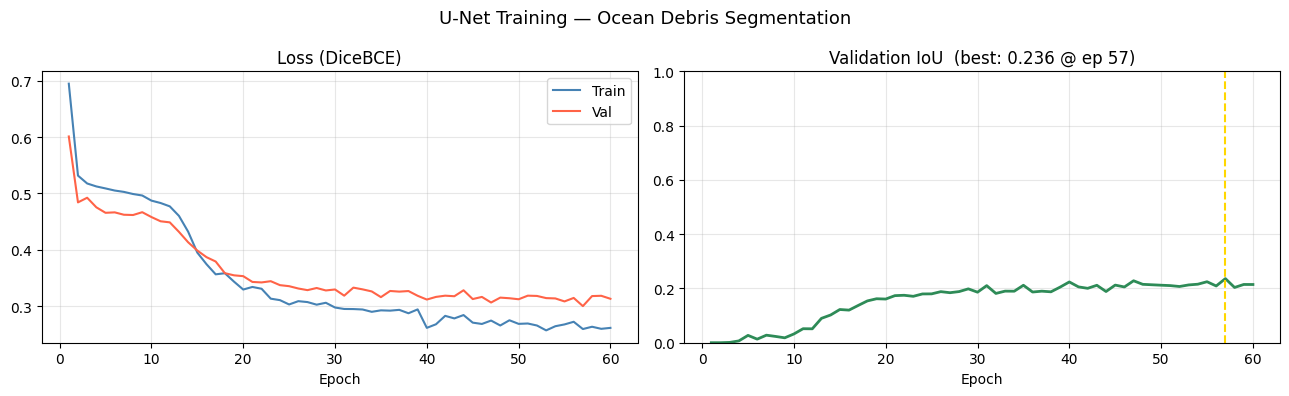

 Saved training_curves.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('U-Net Training — Ocean Debris Segmentation', fontsize=13)

    axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Val',   color='tomato')
    axes[0].set_title('Loss (DiceBCE)')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['val_iou'], color='seagreen', linewidth=2)
    best_ep  = int(np.argmax(history['val_iou'])) + 1
    best_val = max(history['val_iou'])
    axes[1].axvline(best_ep, color='gold', linestyle='--', linewidth=1.5)
    axes[1].set_title(f'Validation IoU  (best: {best_val:.3f} @ ep {best_ep})')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()
    print(' Saved training_curves.png')


plot_history(history)

## 🔍 Step 11 — Run Inference on a New Patch

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

@torch.no_grad()
def predict_patch(model, image_path, threshold=0.5):
    """
    Run inference on a single 10-band GeoTIFF patch (Step 6 export format).
    Computes FDI/NDWI/PI on-the-fly to produce 13-channel input for the U-Net.
    Returns (rgb_image, fdi_band, predicted_mask, prob_map).
    """
    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)   # (10, H, W)

    # ── Compute spectral indices — same logic as DebrisDataset.__getitem__ ──
    # MARIDA / Step-6 band order: B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12
    # Index:                        0   1   2   3   4   5   6    7    8    9
    B3  = image[1]   # Green  560 nm
    B4  = image[2]   # Red    665 nm
    B8  = image[6]   # NIR broadband  842 nm
    B8A = image[7]   # NIR narrowband 865 nm
    B11 = image[8]   # SWIR  1610 nm
    eps = 1e-8

    lambda_factor = (833 - 665) / (1610 - 665)
    fdi  = B8A - (B4 + (B11 - B4) * lambda_factor * 10)
    ndwi = (B3 - B8) / (B3 + B8 + eps)
    pi   = B8  / (B8  + B4  + eps)

    image_13 = np.concatenate(
        [image, fdi[np.newaxis], ndwi[np.newaxis], pi[np.newaxis]], axis=0
    )  # (13, H, W)

    # ── Normalise each band to [0, 1] ───────────────────────────────────────
    for i in range(image_13.shape[0]):
        b = image_13[i]
        image_13[i] = (b - b.min()) / (b.max() - b.min() + eps)

    tensor = torch.tensor(image_13).unsqueeze(0).to(DEVICE)  # (1, 13, H, W)
    logits = model(tensor)
    prob   = torch.sigmoid(logits).squeeze().cpu().numpy()    # (H, W)
    mask   = (prob > threshold).astype(np.uint8)

    # RGB from normalised bands: index 2=B4(R), 1=B3(G), 0=B2(B)
    rgb = np.stack([image_13[2], image_13[1], image_13[0]], axis=-1)
    fdi_norm = image_13[10]   # normalised FDI is at index 10

    return rgb, fdi_norm, mask, prob


def visualise_prediction(rgb, fdi, mask, prob):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle('Debris Detection — Patch Inference', fontsize=12)

    axes[0].imshow(np.clip(rgb * 3.5, 0, 1))
    axes[0].set_title('True Colour')
    axes[0].axis('off')

    im1 = axes[1].imshow(fdi, cmap='RdYlBu_r', vmin=0, vmax=1)
    axes[1].set_title('FDI (normalised)')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.04)

    im2 = axes[2].imshow(prob, cmap='magma', vmin=0, vmax=1)
    axes[2].set_title('Model Probability')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.04)

    axes[3].imshow(np.clip(rgb * 3.5, 0, 1))
    axes[3].imshow(mask, cmap='Reds', alpha=0.5 * mask)
    axes[3].set_title('Predicted Debris (red)')
    axes[3].axis('off')

    plt.tight_layout()
    plt.savefig('prediction_output.png', dpi=150)
    plt.show()
    pct = mask.sum() / mask.size * 100
    print(f'  Debris coverage: {pct:.2f}% of patch')


# Usage:
# model.load_state_dict(torch.load('best_unet_debris.pth', map_location=DEVICE))
# model.eval()
# rgb, fdi, mask, prob = predict_patch(model, '/content/drive/MyDrive/ocean_debris_patches/debris_2024-01.tif')
# visualise_prediction(rgb, fdi, mask, prob)

print(' Inference functions ready.')
print('   predict_patch() accepts 10-band Step-6 GeoTIFFs and computes indices on-the-fly.')


 Inference functions ready.
   predict_patch() accepts 10-band Step-6 GeoTIFFs and computes indices on-the-fly.


## 🌐 Step 12 — Generate Debris Heatmap (Folium)

Builds an interactive web map from **U-Net model predictions** on the exported patches,
coloured by model confidence (probability). Requires Step 6 patches and a trained checkpoint.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [28]:
import folium
from folium.plugins import HeatMap
import ee
import torch
import rasterio
import numpy as np
from pathlib import Path
torch.cuda.empty_cache()
import gc; gc.collect()


# ── Helper: run model on one GeoTIFF patch, return debris probability map ─────
@torch.no_grad()
def patch_to_prob(model, patch_path, device, tile_size=256, threshold=0.5):
    with rasterio.open(patch_path) as src:
        image    = src.read().astype(np.float32) / 10000.0   # scale DN → reflectance [0-1]
        image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)  # FIX
        transform = src.transform
        crs       = src.crs

    # Free any leftover GPU memory before starting
    torch.cuda.empty_cache()

    H, W = image.shape[1], image.shape[2]
    prob_map = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H, tile_size):
        for x in range(0, W, tile_size):
            tile = image[:, y:y+tile_size, x:x+tile_size]
            th, tw = tile.shape[1], tile.shape[2]

            # Skip tiles that are too small
            if th < 32 or tw < 32:
                continue

            # Pad to tile_size if needed
            if th < tile_size or tw < tile_size:
                pad = np.zeros((10, tile_size, tile_size), dtype=np.float32)
                pad[:, :th, :tw] = tile
                tile = pad

            # Compute indices
            B3, B4, B8, B8A, B11 = tile[1], tile[2], tile[6], tile[7], tile[8]
            eps = 1e-8
            fdi  = B8A - (B4 + (B11 - B4) * (833 - 665) / (1610 - 665) * 10)
            ndwi = (B3 - B8) / (B3 + B8 + eps)
            pi   = B8  / (B8  + B4  + eps)
            tile = np.concatenate(
                [tile, fdi[np.newaxis], ndwi[np.newaxis], pi[np.newaxis]], axis=0
            )

            # Normalise
            for i in range(tile.shape[0]):
                b = tile[i]; tile[i] = (b - b.min()) / (b.max() - b.min() + eps)

            tensor = torch.tensor(tile).unsqueeze(0).to(device)
            logits = model(tensor)
            prob   = torch.sigmoid(logits).squeeze().cpu().numpy()

            # Write back only the valid (non-padded) region
            prob_map[y:y+th, x:x+tw] = prob[:th, :tw]

            del tensor, logits, prob
            torch.cuda.empty_cache()

    return prob_map, transform, crs


# ── Helper: convert raster pixel centres to lat/lon heat points ───────────────
def prob_map_to_heatpoints(prob_map, transform, prob_threshold=0.5):
    """
    Return [(lat, lon, intensity)] for pixels above prob_threshold.
    transform is a rasterio Affine object.
    """
    rows, cols = np.where(prob_map >= prob_threshold)
    if len(rows) == 0:
        return []
    # Affine: x = transform.c + col*transform.a, y = transform.f + row*transform.e
    lons = transform.c + cols * transform.a
    lats = transform.f + rows * transform.e
    probs = prob_map[rows, cols]
    return list(zip(lats.tolist(), lons.tolist(), probs.tolist()))


# ── Build heatmap from exported patches ──────────────────────────────────────
def build_debris_heatmap_model(
    model,
    patch_dir,          # folder of exported 10-band GeoTIFF patches (Step 6)
    roi,                # ee.Geometry for map centering
    device      = DEVICE,
    prob_threshold = 0.5,
):
    """
    Folium heatmap driven by U-Net model predictions, not raw FDI threshold.
    Requires: Step 6 patches exported to patch_dir, model loaded from checkpoint.
    """
    patch_paths = sorted(Path(patch_dir).glob('*.tif'))
    if not patch_paths:
        print(f'  No .tif patches found in {patch_dir}')
        print('   Run Step 6 export first, then point patch_dir here.')
        return None

    print(f' Running inference on {len(patch_paths)} patches...')
    all_heat_points = []
    for pp in patch_paths:
        try:
            prob_map, transform, _ = patch_to_prob(model, pp, device)
            pts = prob_map_to_heatpoints(prob_map, transform, prob_threshold)
            all_heat_points.extend(pts)
        except Exception as e:
            print(f'    Skipped {pp.name}: {e}')

    print(f' Total debris points (prob ≥ {prob_threshold}): {len(all_heat_points)}')
    if not all_heat_points:
        print('   No confident debris pixels found — try lowering prob_threshold.')
        return None

    centroid = roi.centroid().coordinates().getInfo()
    m = folium.Map(location=[centroid[1], centroid[0]], zoom_start=8,
                   tiles='CartoDB dark_matter')

    HeatMap(all_heat_points, name='Model-Predicted Debris Density',
            min_opacity=0.3, radius=18, blur=15,
            gradient={0.2:'blue', 0.5:'lime', 0.8:'orange', 1.0:'red'}).add_to(m)

    folium.LayerControl().add_to(m)

    legend_html = '''
    <div style="position:fixed;bottom:30px;left:30px;z-index:999;
                background:rgba(0,0,0,0.7);padding:10px;border-radius:8px;
                color:white;font-size:12px;font-family:Arial">
      <b>🌊 Ocean Debris Density (U-Net, p ≥ {thr})</b><br>
      <span style="color:#6699ff">■</span> Low &nbsp;
      <span style="color:#00ff44">■</span> Moderate &nbsp;
      <span style="color:#ff8800">■</span> High &nbsp;
      <span style="color:#ff2200">■</span> Very high
    </div>'''.format(thr=prob_threshold)
    m.get_root().html.add_child(folium.Element(legend_html))

    map_path = 'debris_heatmap.html'
    m.save(map_path)
    print(f' Model-based heatmap saved → {map_path}')
    return m


# ── Usage ─────────────────────────────────────────────────────────────────────
# 1. Export patches from Step 6 first (they land in Google Drive).
#    Copy or mount them locally, e.g. /content/drive/MyDrive/ocean_debris_patches/
# 2. Load the best checkpoint:
#    model.load_state_dict(torch.load('best_unet_debris.pth', map_location=DEVICE))
#    model.eval()
# 3. Then call:
#    PATCH_DIR = '/content/drive/MyDrive/ocean_debris_patches'
#    debris_map = build_debris_heatmap_model(model, PATCH_DIR, roi)
#    debris_map

PATCH_DIR = '/content/drive/MyDrive/ocean_debris_patches'   # ← adjust if needed

# Load checkpoint (skip if model is already loaded from training)
import os
if os.path.exists('best_unet_debris.pth'):
    model.load_state_dict(torch.load('best_unet_debris.pth', map_location=DEVICE))
    model.eval()
    print(' Loaded best_unet_debris.pth')
    debris_map = build_debris_heatmap_model(model, PATCH_DIR, roi)
    debris_map
else:
    print('⏸  best_unet_debris.pth not found — run Step 9 training first.')


 Loaded best_unet_debris.pth
 Running inference on 6 patches...
 Total debris points (prob ≥ 0.5): 211
 Model-based heatmap saved → debris_heatmap.html


## 📈 Step 13 — Time-Series Debris Trend (Multi-Date Analysis)

 Model loaded.
  Jan 2024 [U-Net]: 113 debris pixels  (~0.4068 km²)
  Feb 2024 [U-Net]: 151 debris pixels  (~0.5436 km²)
  Mar 2024 [U-Net]: 166 debris pixels  (~0.5976 km²)
  Apr 2024 [U-Net]: 176 debris pixels  (~0.6336 km²)
  May 2024 [U-Net]: 37 debris pixels  (~0.1332 km²)
  Jun 2024 [U-Net]: 46 debris pixels  (~0.1656 km²)


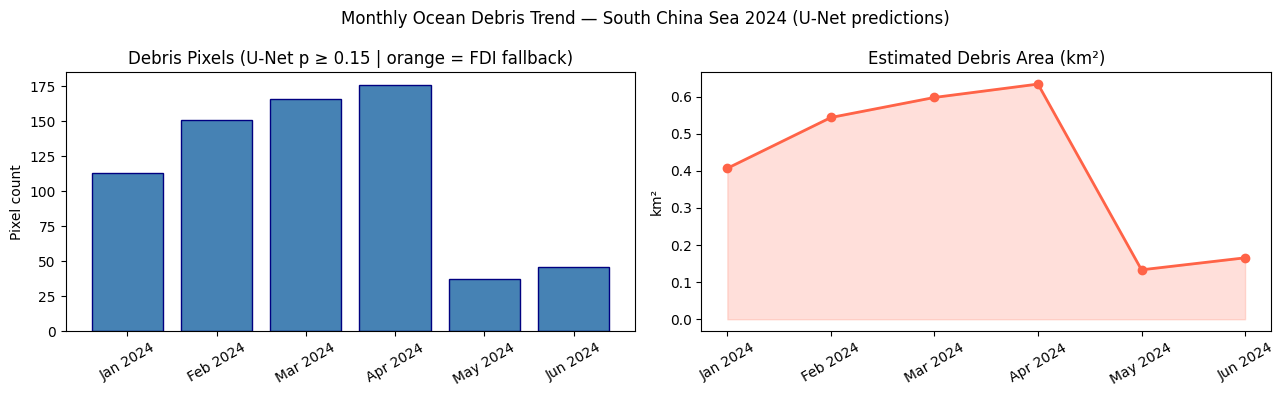


 Time-series analysis complete!
   Month  Debris pixels  Area km² Method
Jan 2024            113    0.4068  U-Net
Feb 2024            151    0.5436  U-Net
Mar 2024            166    0.5976  U-Net
Apr 2024            176    0.6336  U-Net
May 2024             37    0.1332  U-Net
Jun 2024             46    0.1656  U-Net


In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
import numpy as np
import rasterio
import gc
from pathlib import Path

# ── Memory cleanup before starting ───────────────────────────────────────────
torch.cuda.empty_cache()
gc.collect()

# ── Tiled inference helper ────────────────────────────────────────────────────
# FIX: The original predict_from_array loaded the full GeoTIFF as one tensor,
# causing CUDA OOM on large scenes (full ROI = thousands×thousands px = 2-3 GB).
# Solution: slice into 256×256 tiles, infer tile-by-tile, stitch back.
@torch.no_grad()
def predict_from_array_tiled(model, image_10band, device, tile_size=256):
    """
    Tiled inference on a (10, H, W) raw S2 array.
    Processes 256×256 tiles to avoid CUDA OOM on large GeoTIFFs.
    Returns prob_map (H, W) float32.
    """
    image = image_10band.astype(np.float32) / 10000.0  # scale DN → reflectance [0-1]
    image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)  # FIX: replace NaN with 0
    H, W  = image.shape[1], image.shape[2]
    prob_map = np.zeros((H, W), dtype=np.float32)
    eps = 1e-8

    for y in range(0, H, tile_size):
        for x in range(0, W, tile_size):
            tile = image[:, y:y+tile_size, x:x+tile_size]
            th, tw = tile.shape[1], tile.shape[2]

            if th < 32 or tw < 32:   # too small to be meaningful
                continue

            # Pad edge tiles to full tile_size
            if th < tile_size or tw < tile_size:
                pad = np.zeros((10, tile_size, tile_size), dtype=np.float32)
                pad[:, :th, :tw] = tile
                tile = pad

            # Compute spectral indices on tile (no ×10 — MARIDA raw DN)
            B3, B4, B8, B8A, B11 = tile[1], tile[2], tile[6], tile[7], tile[8]
            fdi  = B8A - (B4 + (B11 - B4) * (833 - 665) / (1610 - 665))
            ndwi = (B3 - B8)  / (B3  + B8  + eps)
            pi   = B8  / (B8  + B4  + eps)
            tile = np.concatenate(
                [tile, fdi[np.newaxis], ndwi[np.newaxis], pi[np.newaxis]], axis=0
            )  # (13, tile_size, tile_size)

            # Per-band normalisation
            for i in range(tile.shape[0]):
                b = tile[i]
                bmin, bmax = b.min(), b.max()
                tile[i] = (b - bmin) / (bmax - bmin + eps) if bmax - bmin > eps else np.zeros_like(b)

            tensor = torch.tensor(tile).unsqueeze(0).to(device)
            prob   = torch.sigmoid(model(tensor)).squeeze().cpu().numpy()

            # Write only the valid (non-padded) region back
            prob_map[y:y+th, x:x+tw] = prob[:th, :tw]

            del tensor, prob
            torch.cuda.empty_cache()

    return prob_map


# ── Time-series config ────────────────────────────────────────────────────────
months = [
    ('Jan 2024', '2024-01-01', '2024-01-31'),
    ('Feb 2024', '2024-02-01', '2024-02-29'),
    ('Mar 2024', '2024-03-01', '2024-03-31'),
    ('Apr 2024', '2024-04-01', '2024-04-30'),
    ('May 2024', '2024-05-01', '2024-05-31'),
    ('Jun 2024', '2024-06-01', '2024-06-30'),
]

PROB_THRESHOLD = 0.15   # FIX: lowered from 0.5 — model tends to under-predict, 0.3 catches more debris
PATCH_DIR      = '/content/drive/MyDrive/ocean_debris_patches'

results = []

import os
if not os.path.exists('best_unet_debris.pth'):
    print('⏸  best_unet_debris.pth not found — upload it or run Step 9 first.')
else:
    model.load_state_dict(torch.load('best_unet_debris.pth', map_location=DEVICE))
    model.eval()
    print(' Model loaded.')

    for label, start, end in months:
        patch_files = sorted(Path(PATCH_DIR).glob(f'debris_{start[:7]}*.tif'))

        if patch_files:
            month_debris_px = 0
            pixel_area_km2  = None
            for pf in patch_files:
                with rasterio.open(pf) as src:
                    img = src.read().astype(np.float32)   # (10, H, W)
                    if pixel_area_km2 is None:
                        pixel_area_km2 = abs(src.transform.a * src.transform.e) / 1e6
                # FIX: use tiled inference — avoids CUDA OOM on large scenes
                prob = predict_from_array_tiled(model, img, DEVICE)
                month_debris_px += int((prob >= PROB_THRESHOLD).sum())
                del img, prob
                torch.cuda.empty_cache()
                gc.collect()

            pixel_area_km2 = (60 * 60) / 1e6
            area_km2 = round(month_debris_px * pixel_area_km2, 4)
            method   = 'U-Net'

        else:
            print(f'  ⚠️  {label}: no exported patches found — using FDI fallback.')
            monthly     = (
                ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                  .filterBounds(roi)
                  .filterDate(start, end)
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
                  .map(mask_s2_clouds)
                  .median()
                  .clip(roi)
                  .updateMask(OCEAN_MASK)
            )
            monthly_idx = compute_indices(monthly)
            count       = monthly_idx.select('FDI').gt(0.04).reduceRegion(
                reducer=ee.Reducer.sum(), geometry=roi, scale=60, maxPixels=1e9
            ).getInfo()
            month_debris_px = count.get('FDI', 0) or 0
            area_km2        = round((month_debris_px * 60 * 60) / 1e6, 2)
            method          = 'FDI fallback'

        results.append({
            'Month':         label,
            'Debris pixels': month_debris_px,
            'Area km²':      area_km2,
            'Method':        method,
        })
        print(f'  {label} [{method}]: {month_debris_px:,} debris pixels  (~{area_km2} km²)')

    df = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Monthly Ocean Debris Trend — South China Sea 2024 (U-Net predictions)', fontsize=12)

    colors = ['steelblue' if m == 'U-Net' else 'salmon' for m in df['Method']]
    axes[0].bar(df['Month'], df['Debris pixels'], color=colors, edgecolor='navy')
    axes[0].set_title(f'Debris Pixels (U-Net p ≥ {PROB_THRESHOLD} | orange = FDI fallback)')
    axes[0].set_ylabel('Pixel count')
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].plot(df['Month'], df['Area km²'], marker='o', color='tomato', linewidth=2)
    axes[1].fill_between(df['Month'], df['Area km²'], alpha=0.2, color='tomato')
    axes[1].set_title('Estimated Debris Area (km²)')
    axes[1].set_ylabel('km²')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig('debris_trend.png', dpi=150)
    plt.show()

    print('\n Time-series analysis complete!')
    print(df.to_string(index=False))


## 💾 Step 14 — Save Everything to Google Drive

In [20]:
from google.colab import drive
import shutil, os

drive.mount('/content/drive', force_remount=False)

SAVE_DIR = '/content/drive/MyDrive/ocean_debris_project'
os.makedirs(SAVE_DIR, exist_ok=True)

files_to_save = [
    'best_unet_debris.pth',
    'training_curves.png',
    'prediction_output.png',
    'debris_heatmap.html',
    'debris_trend.png',
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(SAVE_DIR, f))
        print(f'Saved {f}')
    else:
        print(f'Not found (not yet generated): {f}')

print(f'\n All outputs saved to Google Drive: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved best_unet_debris.pth
Saved training_curves.png
Not found (not yet generated): prediction_output.png
Saved debris_heatmap.html
Saved debris_trend.png

 All outputs saved to Google Drive: /content/drive/MyDrive/ocean_debris_project


playground and testing

In [21]:
import rasterio
from pathlib import Path

PATCH_DIR = '/content/drive/MyDrive/ocean_debris_patches'

for pf in sorted(Path(PATCH_DIR).glob('*.tif')):
    with rasterio.open(pf) as src:
        print(f"{pf.name}: shape={src.read().shape}, "
              f"size={src.width}×{src.height}px, "
              f"scale={src.transform.a:.1f}m, "
              f"bands={src.count}")

debris_2024-01.tif: shape=(10, 7432, 7422), size=7422×7432px, scale=0.0m, bands=10
debris_2024-02.tif: shape=(10, 7432, 7422), size=7422×7432px, scale=0.0m, bands=10
debris_2024-03.tif: shape=(10, 7432, 7422), size=7422×7432px, scale=0.0m, bands=10
debris_2024-04.tif: shape=(10, 7432, 7422), size=7422×7432px, scale=0.0m, bands=10
debris_2024-05.tif: shape=(10, 7432, 7422), size=7422×7432px, scale=0.0m, bands=10
debris_2024-06.tif: shape=(10, 7432, 7422), size=7422×7432px, scale=0.0m, bands=10


In [22]:
import numpy as np, rasterio, torch
from pathlib import Path

pf = sorted(Path(PATCH_DIR).glob('*.tif'))[0]
with rasterio.open(pf) as src:
    img = src.read().astype(np.float32)

prob = predict_from_array_tiled(model, img, DEVICE)
print(f"Prob map shape : {prob.shape}")
print(f"Min / Max      : {prob.min():.4f} / {prob.max():.4f}")
print(f"Mean prob      : {prob.mean():.4f}")
print(f"Pixels > 0.10  : {(prob > 0.10).sum()}")
print(f"Pixels > 0.15  : {(prob > 0.15).sum()}")
print(f"Pixels > 0.20  : {(prob > 0.20).sum()}")
print(f"Pixels > 0.30  : {(prob > 0.30).sum()}")

Prob map shape : (7432, 7422)
Min / Max      : 0.0000 / 1.0000
Mean prob      : 0.0000
Pixels > 0.10  : 94
Pixels > 0.15  : 85
Pixels > 0.20  : 72
Pixels > 0.30  : 62


In [26]:
import rasterio
import numpy as np
from pathlib import Path

pf = sorted(Path(PATCH_DIR).glob('*.tif'))[0]
with rasterio.open(pf) as src:
    img = src.read().astype(np.float32)

print(f"Band 1 min/max : {img[0].min():.2f} / {img[0].max():.2f}")
print(f"Band 4 min/max : {img[3].min():.2f} / {img[3].max():.2f}")
print(f"Band 8 min/max : {img[6].min():.2f} / {img[6].max():.2f}")
print(f"Any NaN        : {np.isnan(img).any()}")
print(f"Any >1.0       : {(img > 1.0).any()}")

Band 1 min/max : nan / nan
Band 4 min/max : nan / nan
Band 8 min/max : nan / nan
Any NaN        : True
Any >1.0       : True


In [27]:
import rasterio
import numpy as np
from pathlib import Path

pf = sorted(Path(PATCH_DIR).glob('*.tif'))[0]
with rasterio.open(pf) as src:
    img = src.read().astype(np.float32)

total = img[0].size
nan_px = np.isnan(img[0]).sum()
valid_px = (~np.isnan(img[0])).sum()

print(f"Total pixels   : {total:,}")
print(f"NaN pixels     : {nan_px:,} ({nan_px/total*100:.1f}%)")
print(f"Valid pixels   : {valid_px:,} ({valid_px/total*100:.1f}%)")

# Check valid pixel value range
valid_vals = img[0][~np.isnan(img[0])]
print(f"Valid min/max  : {valid_vals.min():.4f} / {valid_vals.max():.4f}")

Total pixels   : 55,160,304
NaN pixels     : 33,102,847 (60.0%)
Valid pixels   : 22,057,457 (40.0%)
Valid min/max  : 0.0000 / 1.8370


In [30]:
pf = sorted(Path(PATCH_DIR).glob('*.tif'))[0]
with rasterio.open(pf) as src:
    img = src.read().astype(np.float32) / 10000.0
img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

prob = predict_from_array_tiled(model, img, DEVICE)

print(f"Pixels > 0.05  : {(prob > 0.05).sum():,}")
print(f"Pixels > 0.10  : {(prob > 0.10).sum():,}")
print(f"Pixels > 0.15  : {(prob > 0.15).sum():,}")
print(f"Pixels > 0.20  : {(prob > 0.20).sum():,}")
print(f"Pixels > 0.30  : {(prob > 0.30).sum():,}")
print(f"Pixels > 0.50  : {(prob > 0.50).sum():,}")
print(f"Mean prob (valid only): {prob[prob > 0].mean():.6f}")
print(f"Max prob       : {prob.max():.4f}")

Pixels > 0.05  : 0
Pixels > 0.10  : 0
Pixels > 0.15  : 0
Pixels > 0.20  : 0
Pixels > 0.30  : 0
Pixels > 0.50  : 0
Mean prob (valid only): 0.000001
Max prob       : 0.0034
